In [1]:
import matplotlib.pyplot as plt

from superfv import HydroSolverOutput

In [2]:
N = 782

In [3]:
base_path = "/scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/"
schemes = [
    "MUSCL-Hancock",
    "MM4_rtol=1e-5",
    "MM4_rtol=1e-3",
    "MM4_rtol=1e-1",
    "MM8_rtol=1e-5",
    "MM8_rtol=1e-3",
    "MM8_rtol=1e-1",
]

sims = {}
for P0 in [1.0, 10.0, 100.0, 100.0]:
    sims[P0] = {}
    for scheme in schemes:
        sims[P0][scheme] = HydroSolverOutput(base_path + f"{P0=}/{N=}/" + scheme)

Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MUSCL-Hancock/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MM4_rtol=1e-5/params.pkl: Can't get attribute 'gravity' on <module '__main__'>


/home/jp7427/Desktop/superfv/superfv/mesh.py:258: UserWarning: Cupy is not available. Falling back to NumPy.
  warnings.warn("Cupy is not available. Falling back to NumPy.")


Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MM4_rtol=1e-3/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MM4_rtol=1e-1/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MM8_rtol=1e-5/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MM8_rtol=1e-3/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=1.0/N=782/MM8_rtol=1e-1/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Error occurred while unpickling /scratch/gpfs/jp7427/superfv/Rayleigh-Taylor/P0=10.0/N=782/MUSCL-Hancock/params.pkl: Can't get attribute 'gravity' on <modu

vmin=np.float64(0.6292788178142799), vmax=np.float64(2.4998921739116553)


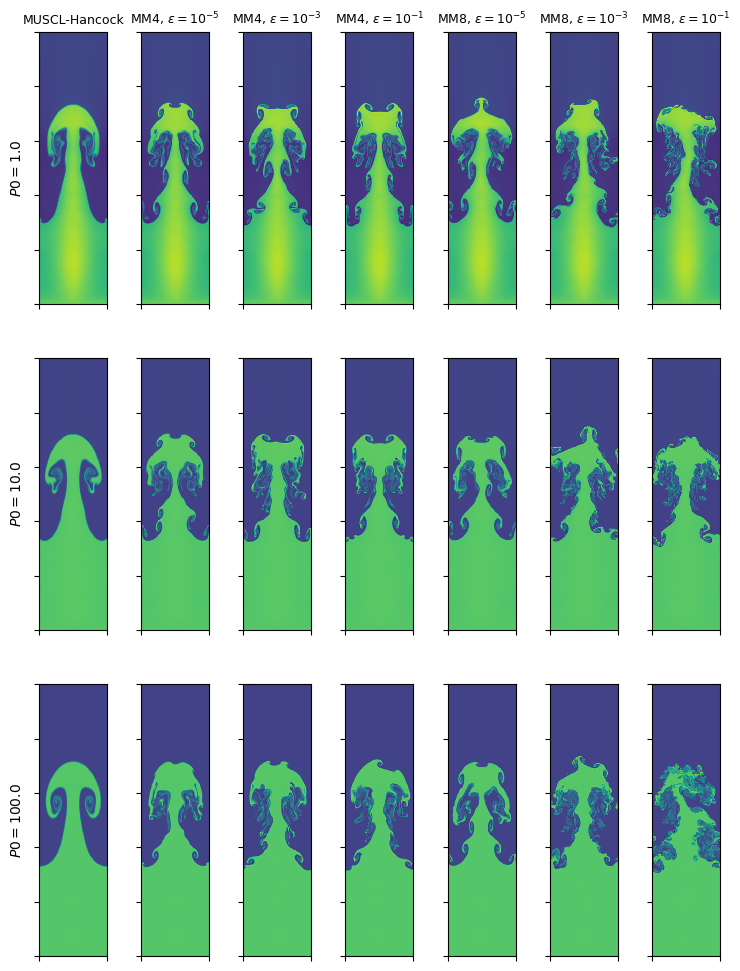

In [11]:
fig, axs = plt.subplots(3, 7, sharex=True, sharey=True, figsize=(9, 12))
fontsize = 9

meshes = []


def plot_density(ax, sim):
    ax.set_aspect("equal")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    x_faces, y_faces, _ = sim.mesh.faces

    mesh = ax.pcolormesh(
        x_faces,
        y_faces,
        sim.snapshot_history[-1].u[0, :, :, 0].T,
    )
    meshes.append(mesh)


axs[0, 0].set_ylabel(r"$P0=1.0$")
axs[1, 0].set_ylabel(r"$P0=10.0$")
axs[2, 0].set_ylabel(r"$P0=100.0$")
axs[0, 0].set_title(r"MUSCL-Hancock", fontsize=fontsize)
plot_density(axs[0, 0], sims[1.0]["MUSCL-Hancock"])
plot_density(axs[1, 0], sims[10.0]["MUSCL-Hancock"])
plot_density(axs[2, 0], sims[100.0]["MUSCL-Hancock"])

axs[0, 1].set_title(r"MM4, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_density(axs[0, 1], sims[1.0]["MM4_rtol=1e-5"])
plot_density(axs[1, 1], sims[10.0]["MM4_rtol=1e-5"])
plot_density(axs[2, 1], sims[100.0]["MM4_rtol=1e-5"])

axs[0, 2].set_title(r"MM4, $\varepsilon=10^{-3}$", fontsize=fontsize)
plot_density(axs[0, 2], sims[1.0]["MM4_rtol=1e-3"])
plot_density(axs[1, 2], sims[10.0]["MM4_rtol=1e-3"])
plot_density(axs[2, 2], sims[100.0]["MM4_rtol=1e-3"])

axs[0, 3].set_title(r"MM4, $\varepsilon=10^{-1}$", fontsize=fontsize)
plot_density(axs[0, 3], sims[1.0]["MM4_rtol=1e-1"])
plot_density(axs[1, 3], sims[10.0]["MM4_rtol=1e-1"])
plot_density(axs[2, 3], sims[100.0]["MM4_rtol=1e-1"])

axs[0, 4].set_title(r"MM8, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_density(axs[0, 4], sims[1.0]["MM8_rtol=1e-5"])
plot_density(axs[1, 4], sims[10.0]["MM8_rtol=1e-5"])
plot_density(axs[2, 4], sims[100.0]["MM8_rtol=1e-5"])

axs[0, 5].set_title(r"MM8, $\varepsilon=10^{-3}$", fontsize=fontsize)
plot_density(axs[0, 5], sims[1.0]["MM8_rtol=1e-3"])
plot_density(axs[1, 5], sims[10.0]["MM8_rtol=1e-3"])
plot_density(axs[2, 5], sims[100.0]["MM8_rtol=1e-3"])

axs[0, 6].set_title(r"MM8, $\varepsilon=10^{-1}$", fontsize=fontsize)
plot_density(axs[0, 6], sims[1.0]["MM8_rtol=1e-1"])
plot_density(axs[1, 6], sims[10.0]["MM8_rtol=1e-1"])
plot_density(axs[2, 6], sims[100.0]["MM8_rtol=1e-1"])

# Decide shared limits afterward
vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)
print(f"{vmin=}, {vmax=}")

# Apply shared limits
for m in meshes:
    m.set_clim(vmin, vmax)

# for start_i in [0, 1, 2]:
#     # Decide shared limits afterward
#     vmin = min(meshes[i].get_array().min() for i in range(start_i, len(meshes), 3))
#     vmax = max(meshes[i].get_array().max() for i in range(start_i, len(meshes), 3))

#     print(f"{vmin=}, {vmax=}")

#     # Apply shared limits
#     for i in range(start_i, len(meshes), 3):
#         meshes[i].set_clim(vmin, vmax)

fig.savefig("rho.png", dpi=300)